In [1]:
# Cell 1 - Startup self-check
from pathlib import Path
from datetime import datetime, timezone, timedelta
import os, sys, json, time, math, random, shutil, gc
from time import perf_counter

import numpy as np
import pandas as pd
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Sampler
import matplotlib.pyplot as plt

REPO_ROOT = Path('/mnt/g/Code/RF_Image_Bmode')
RUN_DIR = REPO_ROOT / 'experiments' / 'dual_input_v1' / '2026-06-13_dualbranch_baseline_50ep'
CONFIG_DIR = RUN_DIR / '01_config'
TRAIN_DIR = RUN_DIR / '02_train'
CHECKPOINT_DIR = TRAIN_DIR / 'checkpoints'
PROBE_TRAIN_DIR = TRAIN_DIR / 'probes' / 'train'
PROBE_VAL_DIR = TRAIN_DIR / 'probes' / 'val'
STABILITY_CSV = TRAIN_DIR / 'stability.csv'
SUMMARY_MD = TRAIN_DIR / 'summary.md'
LOSS_CURVE = TRAIN_DIR / 'loss_curve.png'
PROBE_SAMPLES_JSON = CONFIG_DIR / 'probe_samples.json'

for path in (CHECKPOINT_DIR, PROBE_TRAIN_DIR, PROBE_VAL_DIR):
    path.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rf_cached_dataset import RFCachedDataset
from rf_cgan_models import DualBranchBModeUNet
from rf_cgan_losses import BModeLoss

CONFIG = yaml.safe_load((CONFIG_DIR / 'config.yaml').read_text())
EXPERIMENT_NAME = CONFIG['experiment_name']
assert EXPERIMENT_NAME == 'dualbranch_baseline_50ep'
assert RUN_DIR.name == '2026-06-13_dualbranch_baseline_50ep'

print(datetime.now(timezone(timedelta(hours=8))).strftime('%Y-%m-%d %H:%M:%S %z') + f' | TASK: {EXPERIMENT_NAME}')
print(f'experiment_name={EXPERIMENT_NAME}')
print(f'run_dir={RUN_DIR}')
print(f'model_class={DualBranchBModeUNet.__name__}')
print(f'torch={torch.__version__} cuda={torch.cuda.is_available()} gpu={torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NA"}')


2026-06-13 17:26:15 +0800 | TASK: dualbranch_baseline_50ep
experiment_name=dualbranch_baseline_50ep
run_dir=/mnt/g/Code/RF_Image_Bmode/experiments/dual_input_v1/2026-06-13_dualbranch_baseline_50ep
model_class=DualBranchBModeUNet
torch=2.5.1+cu121 cuda=True gpu=NVIDIA GeForce RTX 4060


In [2]:
# Cell 2 - Frozen config and key paths
print((CONFIG_DIR / 'config.yaml').read_text())
print(f'cache_root={CONFIG["cache_root"]}')
print(f'checkpoint_dir={CHECKPOINT_DIR}')
print(f'probe_train_dir={PROBE_TRAIN_DIR}')
print(f'probe_val_dir={PROBE_VAL_DIR}')

RUN_EPOCHS = int(os.environ.get('RF_BMODE_EPOCHS', CONFIG['epochs']))
RUN_MODE = 'smoke' if RUN_EPOCHS == CONFIG['smoke_epochs'] else 'full'
print(f'run_epochs={RUN_EPOCHS}')
print(f'run_mode={RUN_MODE}')
print('amp=False fp32_only=True')


experiment_name: dualbranch_baseline_50ep
model: DualBranchBModeUNet
cache_root: /mnt/g/rf_training_cache/dual_input_bmode
epochs: 50
smoke_epochs: 3
micro_batch: 2
grad_accum: 3
stratified_per_class: 2
num_workers: 4
optimizer: Adam
lr: 0.0002
loss: "0.84*(1-SSIM3D) + 0.16*L1"
ssim_win: 7
ssim_data_range: 1.0
amp: false
seed: 20260613

cache_root=/mnt/g/rf_training_cache/dual_input_bmode
checkpoint_dir=/mnt/g/Code/RF_Image_Bmode/experiments/dual_input_v1/2026-06-13_dualbranch_baseline_50ep/02_train/checkpoints
probe_train_dir=/mnt/g/Code/RF_Image_Bmode/experiments/dual_input_v1/2026-06-13_dualbranch_baseline_50ep/02_train/probes/train
probe_val_dir=/mnt/g/Code/RF_Image_Bmode/experiments/dual_input_v1/2026-06-13_dualbranch_baseline_50ep/02_train/probes/val
run_epochs=3
run_mode=smoke
amp=False fp32_only=True


In [3]:
# Cell 3 - Data loading and stratified sampler
class StratifiedCategorySampler(Sampler[int]):
    def __init__(self, categories, samples_per_category=2, seed=0):
        self.categories = np.asarray(categories)
        self.samples_per_category = int(samples_per_category)
        self.seed = int(seed)
        self.epoch = 0
        self.category_names = ['carotid', 'muscle', 'phantom']
        self.by_category = {name: np.flatnonzero(self.categories == name).astype(np.int64) for name in self.category_names}
        missing = [name for name, idx in self.by_category.items() if len(idx) == 0]
        if missing:
            raise RuntimeError(f'missing categories: {missing}')
        self.batches_per_epoch = min(len(idx) // self.samples_per_category for idx in self.by_category.values())
        self.num_samples = self.batches_per_epoch * self.samples_per_category * len(self.category_names)

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        shuffled = {name: rng.permutation(idx) for name, idx in self.by_category.items()}
        for b in range(self.batches_per_epoch):
            batch = []
            for name in self.category_names:
                start = b * self.samples_per_category
                end = start + self.samples_per_category
                batch.extend(shuffled[name][start:end].tolist())
            rng.shuffle(batch)
            yield from batch

    def __len__(self):
        return self.num_samples

cache_root = Path(CONFIG['cache_root'])
train_ds = RFCachedDataset(cache_root, 'train')
val_ds = RFCachedDataset(cache_root, 'val')
train_sampler = StratifiedCategorySampler(train_ds.categories, CONFIG['stratified_per_class'], CONFIG['seed'])
train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG['micro_batch'] * CONFIG['grad_accum'],
    sampler=train_sampler,
    num_workers=CONFIG['num_workers'],
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG['micro_batch'] * CONFIG['grad_accum'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=False,
)

for split, ds in [('train', train_ds), ('val', val_ds)]:
    values, counts = np.unique(ds.categories, return_counts=True)
    print(f'{split}_category_counts=' + str({str(v): int(c) for v, c in zip(values, counts)}))
print(f'train_effective_batches={train_sampler.batches_per_epoch} batch_size={CONFIG["micro_batch"] * CONFIG["grad_accum"]}')

batch = next(iter(train_loader))
for key in ['input_rf', 'input_bmode', 'label_bmode']:
    t = batch[key]
    print(f'{key}: shape={tuple(t.shape)} dtype={t.dtype} max_abs={float(t.abs().max()):.6g} nan={bool(torch.isnan(t).any())} inf={bool(torch.isinf(t).any())}')
del batch
gc.collect()


train_category_counts={'carotid': 350, 'muscle': 350, 'phantom': 350}
val_category_counts={'carotid': 75, 'muscle': 75, 'phantom': 75}
train_effective_batches=175 batch_size=6


input_rf: shape=(6, 1536, 64, 32, 32) dtype=torch.float32 max_abs=0.559082 nan=False inf=False
input_bmode: shape=(6, 1, 64, 32, 32) dtype=torch.float32 max_abs=1 nan=False inf=False
label_bmode: shape=(6, 1, 64, 32, 32) dtype=torch.float32 max_abs=1 nan=False inf=False


11

In [4]:
# Cell 4 - Model initialization
seed = int(CONFIG['seed'])
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', 'CUDA required for this run'
model = DualBranchBModeUNet().to(device=device, dtype=torch.float32)
loss_fn = BModeLoss(win_size=CONFIG['ssim_win']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=float(CONFIG['lr']))

param_count = sum(p.numel() for p in model.parameters())
bn_count = sum(1 for m in model.modules() if isinstance(m, nn.BatchNorm3d))
in_count = sum(1 for m in model.modules() if isinstance(m, nn.InstanceNorm3d))
head_bias_mean = float(model.output_head.bias.detach().mean().item())
print(f'param_count={param_count}')
print(f'batchnorm3d_count={bn_count}')
print(f'instancenorm3d_count={in_count}')
print(f'output_head_bias_mean={head_bias_mean:.6g}')
assert in_count == 0
assert abs(head_bias_mean + 2.0) < 1e-6


param_count=7335649
batchnorm3d_count=22
instancenorm3d_count=0
output_head_bias_mean=-2


In [5]:
# Cell 5 - Training loop with gradient accumulation, probes, stability.csv
AXIAL_MM = 0.0362
LATERAL_MM = 0.2
Y_SLICE = 16
CATEGORY_NAMES = ['carotid', 'muscle', 'phantom']

for path in CHECKPOINT_DIR.glob('checkpoint_epoch*.pth'):
    path.unlink()
for path in list(PROBE_TRAIN_DIR.glob('*.png')) + list(PROBE_VAL_DIR.glob('*.png')):
    path.unlink()
for path in (STABILITY_CSV, SUMMARY_MD, LOSS_CURVE):
    if path.exists():
        path.unlink()

stability_rows = []
exception_records = []
best_val_total_so_far = float('inf')

def first_index_by_category(dataset):
    result = {}
    for category in CATEGORY_NAMES:
        matches = np.flatnonzero(dataset.categories == category)
        if matches.size == 0:
            raise RuntimeError(f'no sample for category={category}')
        result[category] = int(matches[0])
    return result

probe_samples = {
    'y_slice': Y_SLICE,
    'note': 'Fixed first sample per category; whole-patch SNR is non-ROI trend only.',
    'train': first_index_by_category(train_ds),
    'val': first_index_by_category(val_ds),
}
PROBE_SAMPLES_JSON.write_text(json.dumps(probe_samples, indent=2), encoding='utf-8')
print('probe_samples=' + json.dumps(probe_samples, ensure_ascii=False))

def to_device_micro(batch, start, end):
    return (
        batch['input_rf'][start:end].to(device, non_blocking=False),
        batch['input_bmode'][start:end].to(device, non_blocking=False),
        batch['label_bmode'][start:end].to(device, non_blocking=False),
    )

def snr_whole_patch(volume):
    arr = volume.detach().float()
    std = torch.std(arr)
    if float(std.item()) == 0.0:
        return float('inf')
    return float((torch.mean(arr) / (std + 1e-12)).item())

@torch.no_grad()
def make_probe(split_name, dataset, indices_by_category, epoch):
    model.eval()
    fig, axes = plt.subplots(3, 3, figsize=(9, 5.2), constrained_layout=True)
    extent = [0, 32 * LATERAL_MM, 64 * AXIAL_MM, 0]
    pred_snrs = {}
    label_snrs = {}
    for row, category in enumerate(CATEGORY_NAMES):
        sample = dataset[indices_by_category[category]]
        input_rf = sample['input_rf'].unsqueeze(0).to(device)
        input_bmode = sample['input_bmode'].unsqueeze(0).to(device)
        label = sample['label_bmode'].unsqueeze(0).to(device)
        pred = model(input_rf, input_bmode)
        arrays = [
            input_bmode[0, 0, :, :, Y_SLICE].detach().cpu().numpy(),
            pred[0, 0, :, :, Y_SLICE].detach().cpu().numpy(),
            label[0, 0, :, :, Y_SLICE].detach().cpu().numpy(),
        ]
        pred_snrs[category] = snr_whole_patch(pred)
        label_snrs[category] = snr_whole_patch(label)
        for col, (title, arr) in enumerate(zip(['baseline', 'pred', 'gt'], arrays)):
            ax = axes[row, col]
            ax.imshow(arr, cmap='gray', vmin=0.0, vmax=1.0, extent=extent, aspect='equal')
            ax.set_title(f'epoch={epoch:03d} {category} {title}', fontsize=8)
            ax.set_xlabel('X mm', fontsize=7)
            ax.set_ylabel('Z mm', fontsize=7)
            ax.tick_params(labelsize=6)
        del sample, input_rf, input_bmode, label, pred
    fig.suptitle(f'{split_name} y={Y_SLICE} XZ slice; whole-patch non-ROI SNR only', fontsize=10)
    out_dir = PROBE_TRAIN_DIR if split_name == 'train' else PROBE_VAL_DIR
    out_path = out_dir / f'{split_name}_epoch{epoch:03d}_y16.png'
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return pred_snrs, label_snrs

def train_one_epoch(epoch):
    model.train()
    train_sampler.set_epoch(epoch)
    totals = {'total': 0.0, 'ssim_term': 0.0, 'l1_term': 0.0, 'pred_mean': 0.0, 'samples': 0}
    optimizer.zero_grad(set_to_none=True)
    for batch in train_loader:
        batch_samples = int(batch['input_rf'].shape[0])
        for start in range(0, batch_samples, CONFIG['micro_batch']):
            end = start + CONFIG['micro_batch']
            input_rf, input_bmode, gt = to_device_micro(batch, start, end)
            pred = model(input_rf, input_bmode)
            total, terms = loss_fn(pred, gt)
            if not torch.isfinite(total):
                raise RuntimeError(f'non-finite train loss at epoch={epoch}: {total.item()}')
            (total / CONFIG['grad_accum']).backward()
            n = int(input_rf.shape[0])
            totals['total'] += float(total.item()) * n
            totals['ssim_term'] += float(terms['ssim_term'].item()) * n
            totals['l1_term'] += float(terms['l1_term'].item()) * n
            totals['pred_mean'] += float(pred.mean().item()) * n
            totals['samples'] += n
            del input_rf, input_bmode, gt, pred, total, terms
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        del batch
    return {k: totals[k] / totals['samples'] for k in ['total', 'ssim_term', 'l1_term', 'pred_mean']}

@torch.no_grad()
def validate_one_epoch(epoch):
    model.eval()
    totals = {'total': 0.0, 'ssim_term': 0.0, 'l1_term': 0.0, 'pred_mean': 0.0, 'samples': 0}
    for batch in val_loader:
        batch_samples = int(batch['input_rf'].shape[0])
        for start in range(0, batch_samples, CONFIG['micro_batch']):
            end = min(start + CONFIG['micro_batch'], batch_samples)
            input_rf, input_bmode, gt = to_device_micro(batch, start, end)
            pred = model(input_rf, input_bmode)
            total, terms = loss_fn(pred, gt)
            if not torch.isfinite(total):
                raise RuntimeError(f'non-finite val loss at epoch={epoch}: {total.item()}')
            n = int(input_rf.shape[0])
            totals['total'] += float(total.item()) * n
            totals['ssim_term'] += float(terms['ssim_term'].item()) * n
            totals['l1_term'] += float(terms['l1_term'].item()) * n
            totals['pred_mean'] += float(pred.mean().item()) * n
            totals['samples'] += n
            del input_rf, input_bmode, gt, pred, total, terms
        del batch
    return {k: totals[k] / totals['samples'] for k in ['total', 'ssim_term', 'l1_term', 'pred_mean']}

run_start = perf_counter()
torch.cuda.reset_peak_memory_stats()
try:
    for epoch in range(1, RUN_EPOCHS + 1):
        epoch_start = perf_counter()
        train_metrics = train_one_epoch(epoch)
        val_metrics = validate_one_epoch(epoch)
        train_snr, train_label_snr = make_probe('train', train_ds, probe_samples['train'], epoch)
        val_snr, val_label_snr = make_probe('val', val_ds, probe_samples['val'], epoch)
        elapsed = perf_counter() - epoch_start
        row = {
            'epoch': epoch,
            'total': train_metrics['total'],
            'ssim_term': train_metrics['ssim_term'],
            'l1_term': train_metrics['l1_term'],
            'pred_mean': train_metrics['pred_mean'],
            'snr_carotid': train_snr['carotid'],
            'snr_muscle': train_snr['muscle'],
            'snr_phantom': train_snr['phantom'],
            'val_total': val_metrics['total'],
            'val_ssim_term': val_metrics['ssim_term'],
            'val_l1_term': val_metrics['l1_term'],
            'val_pred_mean': val_metrics['pred_mean'],
            'val_snr_carotid': val_snr['carotid'],
            'val_snr_muscle': val_snr['muscle'],
            'val_snr_phantom': val_snr['phantom'],
            'label_snr_carotid': train_label_snr['carotid'],
            'label_snr_muscle': train_label_snr['muscle'],
            'label_snr_phantom': train_label_snr['phantom'],
            'epoch_seconds': elapsed,
        }
        stability_rows.append(row)
        pd.DataFrame(stability_rows).to_csv(STABILITY_CSV, index=False)
        if val_metrics['total'] < best_val_total_so_far:
            best_val_total_so_far = val_metrics['total']
            ckpt_path = CHECKPOINT_DIR / f'checkpoint_epoch{epoch:03d}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': CONFIG,
                'train_metrics': train_metrics,
                'val_metrics': val_metrics,
            }, ckpt_path)
        if epoch % 5 == 0 or epoch == RUN_EPOCHS:
            ckpt_path = CHECKPOINT_DIR / f'checkpoint_epoch{epoch:03d}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': CONFIG,
                'train_metrics': train_metrics,
                'val_metrics': val_metrics,
            }, ckpt_path)
        print(
            f'epoch={epoch:03d} total={train_metrics["total"]:.6f} '
            f'ssim_term={train_metrics["ssim_term"]:.6f} l1_term={train_metrics["l1_term"]:.6f} '
            f'val_total={val_metrics["total"]:.6f} pred_mean={train_metrics["pred_mean"]:.6f} '
            f'elapsed={elapsed:.1f}s',
            flush=True,
        )
except Exception as exc:
    exception_records.append(repr(exc))
    print('EXCEPTION_RECORD=' + repr(exc), flush=True)
    raise
finally:
    total_train_seconds = perf_counter() - run_start
    max_cuda_gb = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0.0
    print(f'total_train_seconds={total_train_seconds:.1f}')
    print(f'cuda_max_memory_allocated_gb={max_cuda_gb:.6g}')


probe_samples={"y_slice": 16, "note": "Fixed first sample per category; whole-patch SNR is non-ROI trend only.", "train": {"carotid": 0, "muscle": 350, "phantom": 700}, "val": {"carotid": 0, "muscle": 75, "phantom": 150}}


epoch=001 total=0.768208 ssim_term=0.881946 l1_term=0.171084 val_total=0.797122 pred_mean=0.498934 elapsed=940.7s


epoch=002 total=0.737317 ssim_term=0.854858 l1_term=0.120229 val_total=0.752035 pred_mean=0.501876 elapsed=936.8s


epoch=003 total=0.734548 ssim_term=0.852231 l1_term=0.116709 val_total=0.735619 pred_mean=0.509335 elapsed=891.9s


total_train_seconds=2769.9
cuda_max_memory_allocated_gb=4.72052


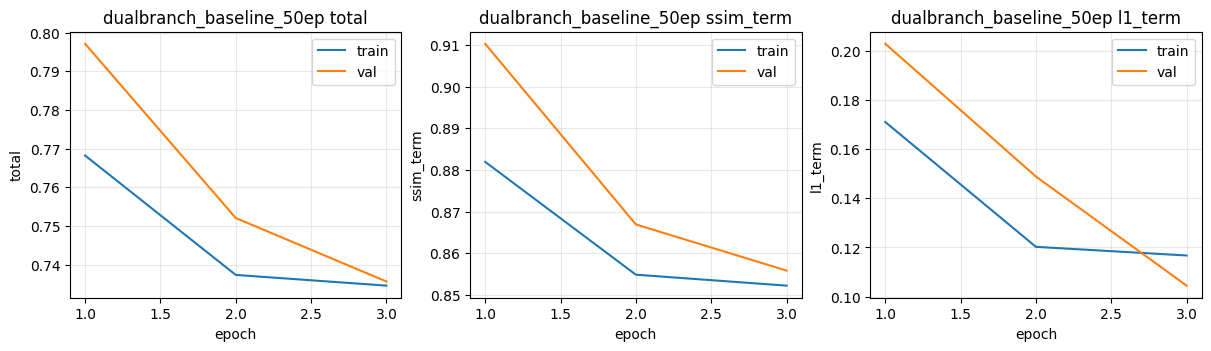

loss_curve=/mnt/g/Code/RF_Image_Bmode/experiments/dual_input_v1/2026-06-13_dualbranch_baseline_50ep/02_train/loss_curve.png
 epoch    total  val_total  ssim_term  val_ssim_term  l1_term  val_l1_term
     1 0.768208   0.797122   0.881946       0.910295 0.171084     0.202966
     2 0.737317   0.752035   0.854858       0.866923 0.120229     0.148873
     3 0.734548   0.735619   0.852231       0.855846 0.116709     0.104430


In [6]:
# Cell 6 - Loss curves
history = pd.read_csv(STABILITY_CSV)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
for ax, metric in zip(axes, ['total', 'ssim_term', 'l1_term']):
    ax.plot(history['epoch'], history[metric], label='train')
    val_metric = 'val_' + metric
    if val_metric in history:
        ax.plot(history['epoch'], history[val_metric], label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel(metric)
    ax.set_title(f'{EXPERIMENT_NAME} {metric}')
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.savefig(LOSS_CURVE, dpi=150)
plt.show()
print(f'loss_curve={LOSS_CURVE}')
print(history[['epoch','total','val_total','ssim_term','val_ssim_term','l1_term','val_l1_term']].to_string(index=False))


In [7]:
# Cell 7 - Training cleanup: keep best checkpoint by val_total
history = pd.read_csv(STABILITY_CSV)
best_idx = int(history['val_total'].idxmin())
best_epoch = int(history.loc[best_idx, 'epoch'])
best_val_total = float(history.loc[best_idx, 'val_total'])
best_ckpt = CHECKPOINT_DIR / f'checkpoint_epoch{best_epoch:03d}.pth'
if not best_ckpt.exists():
    best_ckpt = CHECKPOINT_DIR / f'checkpoint_epoch{int(history["epoch"].iloc[-1]):03d}.pth'
    print(f'best checkpoint epoch was not saved by interval; using final checkpoint: {best_ckpt}')
for ckpt in CHECKPOINT_DIR.glob('checkpoint_epoch*.pth'):
    if ckpt != best_ckpt:
        ckpt.unlink()
print(f'kept_checkpoint={best_ckpt}')
print(f'best_epoch={best_epoch} best_val_total={best_val_total:.6f}')


kept_checkpoint=/mnt/g/Code/RF_Image_Bmode/experiments/dual_input_v1/2026-06-13_dualbranch_baseline_50ep/02_train/checkpoints/checkpoint_epoch003.pth
best_epoch=3 best_val_total=0.735619


In [8]:
# Cell 8 - Automatic summary
history = pd.read_csv(STABILITY_CSV)
best_idx = int(history['val_total'].idxmin())
best = history.loc[best_idx]
final = history.iloc[-1]
pred_mean_start = float(history['pred_mean'].iloc[0])
pred_mean_end = float(history['pred_mean'].iloc[-1])
summary = f"""# {EXPERIMENT_NAME} Summary

- run_mode: {RUN_MODE}
- total_epochs: {int(history['epoch'].iloc[-1])}
- training_seconds: {total_train_seconds:.1f}
- cuda_max_memory_allocated_gb: {max_cuda_gb:.6g}
- best_epoch: {int(best['epoch'])}
- best_val_total: {float(best['val_total']):.6f}
- best_val_ssim_term: {float(best['val_ssim_term']):.6f}
- best_val_l1_term: {float(best['val_l1_term']):.6f}
- final_snr_pred_carotid: {float(final['snr_carotid']):.6f}
- final_snr_pred_muscle: {float(final['snr_muscle']):.6f}
- final_snr_pred_phantom: {float(final['snr_phantom']):.6f}
- final_snr_label_carotid: {float(final['label_snr_carotid']):.6f}
- final_snr_label_muscle: {float(final['label_snr_muscle']):.6f}
- final_snr_label_phantom: {float(final['label_snr_phantom']):.6f}
- pred_mean_start: {pred_mean_start:.6f}
- pred_mean_end: {pred_mean_end:.6f}
- abnormal_records: {exception_records if exception_records else 'none'}

Note: whole-patch SNR is non-ROI and trend-only. No image quality claim is made here.
"""
SUMMARY_MD.write_text(summary, encoding='utf-8')
print(summary)
print('STABILITY_CSV_FULL')
print(history.to_csv(index=False))


# dualbranch_baseline_50ep Summary

- run_mode: smoke
- total_epochs: 3
- training_seconds: 2769.9
- cuda_max_memory_allocated_gb: 4.72052
- best_epoch: 3
- best_val_total: 0.735619
- best_val_ssim_term: 0.855846
- best_val_l1_term: 0.104430
- final_snr_pred_carotid: 14.305232
- final_snr_pred_muscle: 9.832978
- final_snr_pred_phantom: 5.153594
- final_snr_label_carotid: 5.678550
- final_snr_label_muscle: 6.177583
- final_snr_label_phantom: 3.851809
- pred_mean_start: 0.498934
- pred_mean_end: 0.509335
- abnormal_records: none

Note: whole-patch SNR is non-ROI and trend-only. No image quality claim is made here.

STABILITY_CSV_FULL
epoch,total,ssim_term,l1_term,pred_mean,snr_carotid,snr_muscle,snr_phantom,val_total,val_ssim_term,val_l1_term,val_pred_mean,val_snr_carotid,val_snr_muscle,val_snr_phantom,label_snr_carotid,label_snr_muscle,label_snr_phantom,epoch_seconds
1,0.7682084202766418,0.881946413289933,0.1710841208980197,0.4989342807304291,8.266858100891113,2.6858890056610107,0.83543